# Task 1: Extract Data

Retrieve weather data from the OpenWeather API using Python.

Requirements:

- Connect to the API using your API key.
- Extract weather information for at least 3 cities.
- Retrieve relevant fields such as:
  - City Name
  - Temperature
  - Humidity
  - Weather Condition
  - Wind Speed
  - Date and Time

Expected Output:

- Raw weather data successfully extracted from the API.


In [2]:
pip install requests pandas

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: C:\Users\IT\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [1]:
import requests
import json
import pandas as pd
from datetime import datetime

In [56]:
api_key='Venk@#Tesh54'

In [9]:
cities = ["Delhi","Mumbai","Chennai","Kolkata","Kochi","Bhopal","shimla","Lacknow"]

In [10]:
weather_data=[]

In [11]:
for city in cities:
    url = f"https://api.openweathermap.org/data/2.5/weather?q={city}&appid={api_key}&units=metric"

    response = requests.get(url)

    if response.status_code == 200:
        data = response.json()

        weather_data.append({
            "City": data["name"],
            "Temperature": data["main"]["temp"],
            "Humidity": data["main"]["humidity"],
            "Weather": data["weather"][0]["description"],
            "wind_speed" : data["wind"]["speed"],
            "Date & Time": datetime.fromtimestamp(data["dt"]).strftime("%Y-%m-%d %H:%M:%S")
        })

df = pd.DataFrame(weather_data)

print(df)


      City  Temperature  Humidity           Weather  wind_speed  \
0    Delhi        36.07        35         clear sky        4.67   
1   Mumbai        28.93        72        few clouds        4.50   
2  Chennai        31.99        62   overcast clouds        1.79   
3  Kolkata        30.15        75   overcast clouds        5.62   
4    Kochi        25.51        88   overcast clouds        1.34   
5   Bhopal        28.77        61  scattered clouds        6.41   
6   Shimla        21.35        57         clear sky        0.91   

           Date & Time  
0  2026-07-16 08:02:27  
1  2026-07-16 08:00:27  
2  2026-07-16 08:04:47  
3  2026-07-16 07:59:26  
4  2026-07-16 07:56:01  
5  2026-07-16 08:05:33  
6  2026-07-16 08:06:50  


# Task 2: Transform Data

Clean and prepare the extracted data.

Requirements:

- Organize the data into a structured format using Pandas.
- Rename columns where necessary.
- Convert data types if required.
- Create a clean dataset ready for analysis.

Expected Output:

- Cleaned and transformed the weather dataset.


In [12]:
df.head()

,City,Temperature,Humidity,Weather,wind_speed,Date & Time
0,Delhi,36.07,35,clear sky,4.67,2026-07-16 08:02:27
1,Mumbai,28.93,72,few clouds,4.50,2026-07-16 08:00:27
2,Chennai,31.99,62,overcast clouds,1.79,2026-07-16 08:04:47
3,Kolkata,30.15,75,overcast clouds,5.62,2026-07-16 07:59:26
4,Kochi,25.51,88,overcast clouds,1.34,2026-07-16 07:56:01


In [13]:
df.rename(columns={
    "Temperature":"Temperature (°C)",
    "Humidity":"Humidity (%)",
    "Weather":"Weather Condition",
    "Wind Speed":"Wind Speed (m/s)"
}, inplace=True)

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   City               7 non-null      str    
 1   Temperature (°C)   7 non-null      float64
 2   Humidity (%)       7 non-null      int64  
 3   Weather Condition  7 non-null      str    
 4   wind_speed         7 non-null      float64
 5   Date & Time        7 non-null      str    
dtypes: float64(2), int64(1), str(3)
memory usage: 468.0 bytes


In [15]:
df["Date & Time"] = pd.to_datetime(df["Date & Time"])

In [16]:
df.isnull().sum()

City                 0
Temperature (°C)     0
Humidity (%)         0
Weather Condition    0
wind_speed           0
Date & Time          0
dtype: int64

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   City               7 non-null      str           
 1   Temperature (°C)   7 non-null      float64       
 2   Humidity (%)       7 non-null      int64         
 3   Weather Condition  7 non-null      str           
 4   wind_speed         7 non-null      float64       
 5   Date & Time        7 non-null      datetime64[us]
dtypes: datetime64[us](1), float64(2), int64(1), str(2)
memory usage: 468.0 bytes


In [19]:
df

,City,Temperature (°C),Humidity (%),Weather Condition,wind_speed,Date & Time
0,Delhi,36.07,35,clear sky,4.67,2026-07-16 08:02:27
1,Mumbai,28.93,72,few clouds,4.50,2026-07-16 08:00:27
2,Chennai,31.99,62,overcast clouds,1.79,2026-07-16 08:04:47
3,Kolkata,30.15,75,overcast clouds,5.62,2026-07-16 07:59:26
4,Kochi,25.51,88,overcast clouds,1.34,2026-07-16 07:56:01
5,Bhopal,28.77,61,scattered clouds,6.41,2026-07-16 08:05:33
6,Shimla,21.35,57,clear sky,0.91,2026-07-16 08:06:50


# Task 3: Load Data

Store the transformed data for future analysis.

Options:

- CSV File
- Excel File
- SQLite Database 

Expected Output:

- Processed weather data saved successfully.


In [20]:
df.to_csv("weather_data.csv", index=False)

# Task 4: Basic Analysis

Perform simple analysis on the collected weather data.

Examples:

- Compare temperatures across cities.
- Identify the city with the highest humidity.
- Compare weather conditions.

Expected Output:

- Short summary of findings.



In [21]:
print("----- Weather Analysis Summary -----")

print("\nTemperature Comparison")
print(df[["City", "Temperature (°C)"]])

print("\nHighest Temperature")
highest_temp = df.loc[df["Temperature (°C)"].idxmax()]
print(highest_temp["City"], "-", highest_temp["Temperature (°C)"], "°C")

print("\nHighest Humidity")
highest_humidity = df.loc[df["Humidity (%)"].idxmax()]
print(highest_humidity["City"], "-", highest_humidity["Humidity (%)"], "%")

print("\nWeather Conditions")
print(df[["City", "Weather Condition"]])

print("\nAverage Temperature")
average_temp = df["Temperature (°C)"].mean()
print(round(average_temp,2), "°C")

----- Weather Analysis Summary -----

Temperature Comparison
      City  Temperature (°C)
0    Delhi             36.07
1   Mumbai             28.93
2  Chennai             31.99
3  Kolkata             30.15
4    Kochi             25.51
5   Bhopal             28.77
6   Shimla             21.35

Highest Temperature
Delhi - 36.07 °C

Highest Humidity
Kochi - 88 %

Weather Conditions
      City Weather Condition
0    Delhi         clear sky
1   Mumbai        few clouds
2  Chennai   overcast clouds
3  Kolkata   overcast clouds
4    Kochi   overcast clouds
5   Bhopal  scattered clouds
6   Shimla         clear sky

Average Temperature
28.97 °C


# Task 5: Data visualization

In [24]:
# 1. Temparature comparision between Indian Cities
import matplotlib.pyplot as plt
df.columns

Index(['City', 'Temperature (°C)', 'Humidity (%)', 'Weather Condition',
       'wind_speed', 'Date & Time'],
      dtype='str')

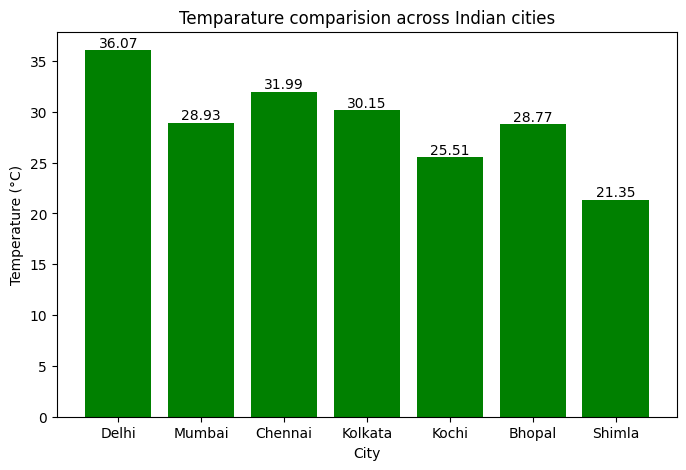

<Figure size 640x480 with 0 Axes>

In [52]:
plt.figure(figsize=(8,5))
bars =plt.bar(df["City"],
        df["Temperature (°C)"],color="green")
plt.title("Temparature comparision across Indian cities")
plt.xlabel("City")
plt.ylabel("Temperature (°C)")
plt.bar_label(bars)
plt.show()
plt.savefig("temperature_chart.jpeg")

In [ ]:
# 2. Humidity comparision between cities


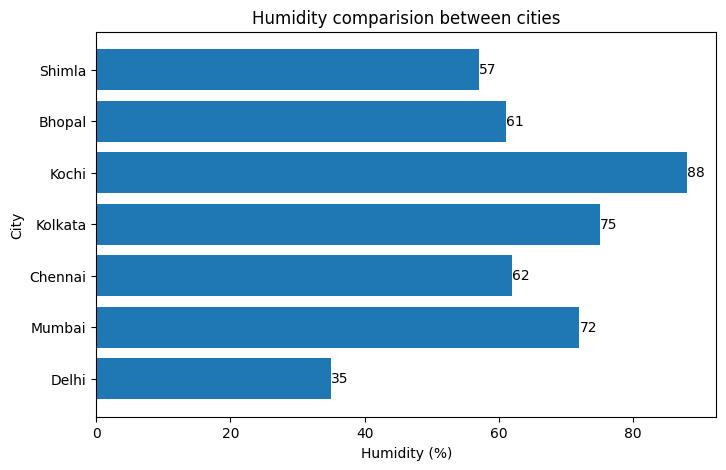

<Figure size 640x480 with 0 Axes>

In [53]:
plt.figure(figsize=(8,5))
bar= plt.barh(df["City"],df["Humidity (%)"])
plt.title("Humidity comparision between cities")
plt.xlabel("Humidity (%)")
plt.ylabel("City")
plt.bar_label(bar)
plt.show()
plt.savefig("humidity_chart.jpeg")

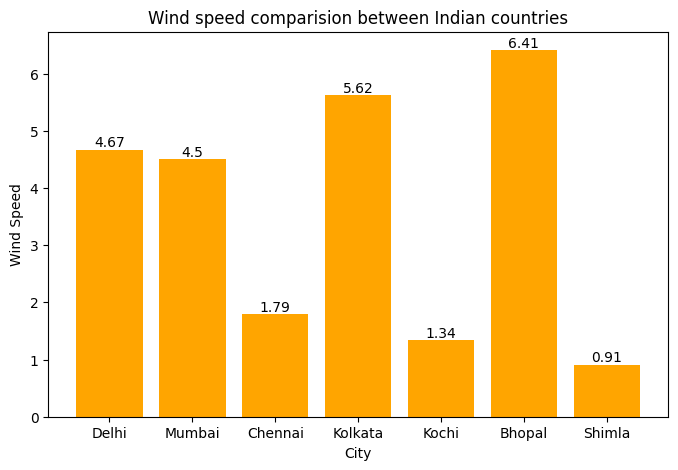

<Figure size 640x480 with 0 Axes>

In [54]:
# 3. Wind speed comparision between Indian countries
plt.figure(figsize=(8,5))
bars= plt.bar(df["City"],
       df["wind_speed"],
             color="Orange")

plt.title("Wind speed comparision between Indian countries")
plt.xlabel("City")
plt.ylabel("Wind Speed")

plt.bar_label(bars)
plt.show()
plt.savefig("wind speed_chart.jpeg")

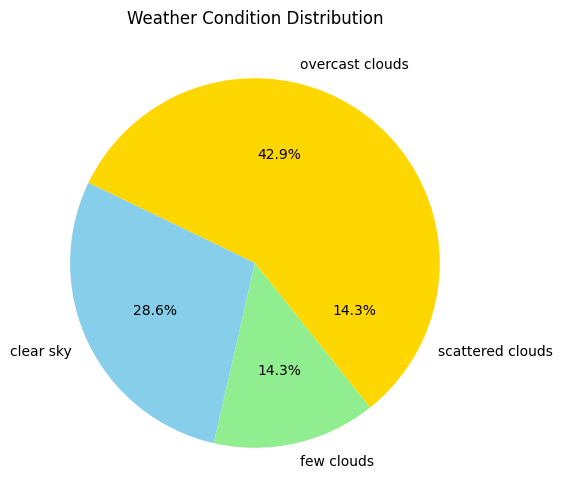

<Figure size 640x480 with 0 Axes>

In [55]:
# 4.Weather Condition in pie chart
weather_counts = df["Weather Condition"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(weather_counts,
        labels=weather_counts.index,
        autopct="%1.1f%%",
        colors=["gold","skyblue","lightgreen"])

plt.title("Weather Condition Distribution")

plt.show()
plt.savefig("weather condition_chart.jpeg")